# Model Optimization

## Importing the libraries

In [1]:
import copy
import random
import matplotlib.pyplot as plt
import numpy as np

import torch
import torch.nn as nn

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Importing the dataset

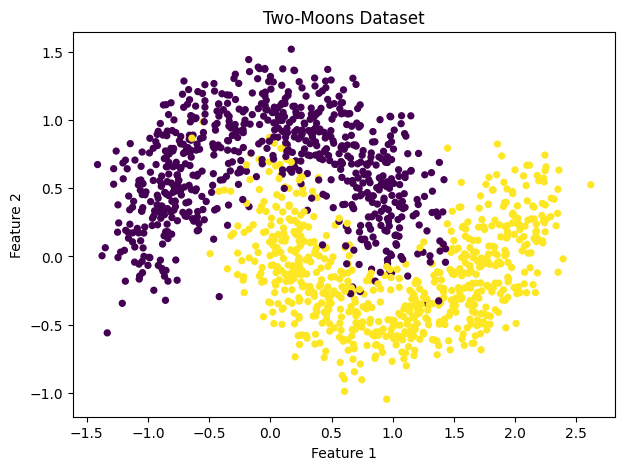

In [4]:
X, y = make_moons(n_samples = 1400, noise = 0.22, random_state = 42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify = y
)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, s=18)
plt.title("Two-Moons Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## Creating the model

In [5]:
class OptimizationModel(nn.Module):

    def __init__(self, batch_norm = False, dropout = 0.0):

        super().__init__()

        layers = [nn.Linear(2, 32)]

        if batch_norm:
            layers.append(nn.BatchNorm1d(32))

        layers.append(nn.ReLU())

        if dropout > 0:
            layers.append(nn.Dropout(dropout))

        layers.append(nn.Linear(32, 32))

        if batch_norm:
            layers.append(nn.BatchNorm1d(32))

        layers.append(nn.ReLU())

        if dropout > 0:
            layers.append(nn.Dropout(dropout))

        layers.append(nn.Linear(32, 2))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


def accuracy(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in loader:

            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            predictions = model(X_batch).argmax(dim=1)
            correct += (predictions == y_batch).sum().item()
            total += y_batch.size(0)

    return correct / total

criterion = nn.CrossEntropyLoss()

## Weight Initialization

In [6]:
def initialize_weights(model, method="xavier"):

    for layer in model.modules():

        if isinstance(layer, nn.Linear):

            if method == "xavier":
                nn.init.xavier_uniform_(layer.weight)

            elif method == "he":
                nn.init.kaiming_uniform_(layer.weight, nonlinearity = "relu")

            elif method == "zeros":
                nn.init.zeros_(layer.weight)

            else:
                raise ValueError("Unknown initialization method")

            nn.init.zeros_(layer.bias)

for method in ["xavier", "he"]:
    model = OptimizationModel().to(DEVICE)
    initialize_weights(model, method = method)
    print(method.capitalize(), "initial weight mean:", model.network[0].weight.mean().item())

Xavier initial weight mean: -0.025538025423884392
He initial weight mean: 0.015311747789382935


In [7]:
def train_model(
    model,
    optimizer,
    epochs = 80,
    loader = train_loader,
    scheduler = None,
    l1_lambda = 0.0,
    early_stopping_patience = None
):
    history = {"train_loss": [], "test_loss": [], "test_accuracy": [], "lr": []}
    best_state = None
    best_loss = float("inf")
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            if l1_lambda > 0:
                l1_penalty = sum(parameter.abs().sum() for parameter in model.parameters())
                loss = loss + l1_lambda * l1_penalty

            loss.backward()
            optimizer.step()
            running_loss += loss.item() * X_batch.size(0)

        train_loss = running_loss / len(loader.dataset)

        model.eval()
        test_loss_total = 0.0

        with torch.no_grad():
            for X_batch, y_batch in test_loader:

                X_batch = X_batch.to(DEVICE)
                y_batch = y_batch.to(DEVICE)
                test_loss_total += criterion(model(X_batch), y_batch).item() * X_batch.size(0)

        test_loss = test_loss_total / len(test_loader.dataset)

        history["train_loss"].append(train_loss)
        history["test_loss"].append(test_loss)
        history["test_accuracy"].append(accuracy(model, test_loader))
        history["lr"].append(optimizer.param_groups[0]["lr"])

        if early_stopping_patience is not None:
            if test_loss < best_loss - 1e-5:
                best_loss = test_loss
                best_state = copy.deepcopy(model.state_dict())
                patience_counter = 0

            else:
                patience_counter += 1

                if patience_counter >= early_stopping_patience:
                    print(f"Early stopping at epoch {epoch + 1}")
                    break

        if scheduler is not None:
            scheduler.step()

    if best_state is not None:
        model.load_state_dict(best_state)

    return history


def plot_history(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)
    plt.figure(figsize = (8, 5))
    plt.plot(epochs, history["train_loss"], label = "Train Loss")
    plt.plot(epochs, history["test_loss"], label = "Test Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.show()

## Batch Normalization

In [8]:
plain_model = OptimizationModel(batch_norm = False).to(DEVICE)
bn_model = OptimizationModel(batch_norm = True).to(DEVICE)

initialize_weights(plain_model, "he")
initialize_weights(bn_model, "he")

plain_history = train_model(
    plain_model, torch.optim.SGD(plain_model.parameters(), lr = 0.08), epochs = 60
)

bn_history = train_model(
    bn_model, torch.optim.SGD(bn_model.parameters(), lr = 0.08), epochs = 60
)

print("Without BatchNorm accuracy:", round(accuracy(plain_model, test_loader), 4))
print("With BatchNorm accuracy:", round(accuracy(bn_model, test_loader), 4))

Without BatchNorm accuracy: 0.9321
With BatchNorm accuracy: 0.9357


## Dropout

In [9]:
dropout_model = OptimizationModel(dropout = 0.30).to(DEVICE)
initialize_weights(dropout_model, "he")

dropout_history = train_model(
    dropout_model,
    torch.optim.Adam(dropout_model.parameters(), lr = 0.01),
    epochs = 80,
)

print("Dropout test accuracy:", round(accuracy(dropout_model, test_loader), 4))

Dropout test accuracy: 0.9357


## Early Stopping

In [10]:
early_stop_model = OptimizationModel(dropout = 0.20).to(DEVICE)
initialize_weights(early_stop_model, "he")

early_stop_history = train_model(
    early_stop_model,
    torch.optim.Adam(early_stop_model.parameters(), lr = 0.01),
    epochs = 150,
    early_stopping_patience = 12,
)

print("Best model test accuracy:", round(accuracy(early_stop_model, test_loader), 4))

Early stopping at epoch 36
Best model test accuracy: 0.925


## Learning Rate Scheduling

In [11]:
scheduler_model = OptimizationModel().to(DEVICE)
initialize_weights(scheduler_model, "he")

optimizer = torch.optim.SGD(scheduler_model.parameters(), lr = 0.10)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size = 20, gamma = 0.4)

scheduler_history = train_model(
    scheduler_model,
    optimizer,
    epochs = 60,
    scheduler = scheduler,
)

print("Learning rates used:", [round(lr, 5) for lr in scheduler_history["lr"][::20]])

Learning rates used: [0.1, 0.04, 0.016]


## Gradient Descent, Stochastic Gradient Descent (SGD)

In [12]:
full_batch_loader = DataLoader(train_dataset, batch_size = len(train_dataset), shuffle = True)

full_batch_model = OptimizationModel().to(DEVICE)
sgd_model = OptimizationModel().to(DEVICE)

initialize_weights(full_batch_model, "he")
initialize_weights(sgd_model, "he")

full_batch_history = train_model(
    full_batch_model,
    torch.optim.SGD(full_batch_model.parameters(), lr = 0.20),
    epochs = 50,
    loader = full_batch_loader,
)

sgd_history = train_model(
    sgd_model,
    torch.optim.SGD(sgd_model.parameters(), lr = 0.08),
    epochs = 50,
    loader = train_loader,
)

print("Full-batch accuracy:", round(accuracy(full_batch_model, test_loader), 4))
print("Mini-batch SGD accuracy:", round(accuracy(sgd_model, test_loader), 4))

Full-batch accuracy: 0.8929
Mini-batch SGD accuracy: 0.9286


## Momentum

In [13]:
momentum_model = OptimizationModel().to(DEVICE)

initialize_weights(momentum_model, "he")

momentum_optimizer = torch.optim.SGD(
    momentum_model.parameters(), lr = 0.05, momentum = 0.9
)

momentum_history = train_model(momentum_model, momentum_optimizer, epochs = 60)

print("Momentum test accuracy:", round(accuracy(momentum_model, test_loader), 4))

Momentum test accuracy: 0.9286


## RMSProp

In [14]:
rmsprop_model = OptimizationModel().to(DEVICE)
initialize_weights(rmsprop_model, "he")

rmsprop_optimizer = torch.optim.RMSprop(rmsprop_model.parameters(), lr = 0.01, alpha = 0.99)
rmsprop_history = train_model(rmsprop_model, rmsprop_optimizer, epochs = 60)

print("RMSProp test accuracy:", round(accuracy(rmsprop_model, test_loader), 4))

RMSProp test accuracy: 0.9286


## Adam, AdamW

In [15]:
adam_model = OptimizationModel().to(DEVICE)
adamw_model = OptimizationModel().to(DEVICE)

initialize_weights(adam_model, "he")
initialize_weights(adamw_model, "he")

adam_history = train_model(
    adam_model,
    torch.optim.Adam(adam_model.parameters(), lr = 0.01),
    epochs = 60,
)

adamw_history = train_model(
    adamw_model,
    torch.optim.AdamW(adamw_model.parameters(), lr = 0.01, weight_decay = 1e-2),
    epochs = 60,
)

print("Adam test accuracy:", round(accuracy(adam_model, test_loader), 4))
print("AdamW test accuracy:", round(accuracy(adamw_model, test_loader), 4))

Adam test accuracy: 0.9214
AdamW test accuracy: 0.9286


## Adagrad

In [16]:
adagrad_model = OptimizationModel().to(DEVICE)
initialize_weights(adagrad_model, "he")

adagrad_optimizer = torch.optim.Adagrad(adagrad_model.parameters(), lr = 0.05)
adagrad_history = train_model(adagrad_model, adagrad_optimizer, epochs = 60)

print("Adagrad test accuracy:", round(accuracy(adagrad_model, test_loader), 4))

Adagrad test accuracy: 0.9393


## Learning Rate Decay

In [17]:
decay_model = OptimizationModel().to(DEVICE)
initialize_weights(decay_model, "he")

decay_optimizer = torch.optim.SGD(decay_model.parameters(), lr = 0.10)
decay_scheduler = torch.optim.lr_scheduler.ExponentialLR(decay_optimizer, gamma = 0.95)

decay_history = train_model(
    decay_model,
    decay_optimizer,
    epochs = 50,
    scheduler = decay_scheduler,
)

print("First learning rate:", round(decay_history["lr"][0], 5))
print("Last learning rate:", round(decay_history["lr"][-1], 5))

First learning rate: 0.1
Last learning rate: 0.0081


## L1 & L2 Regularization

In [18]:
l1_model = OptimizationModel().to(DEVICE)
l2_model = OptimizationModel().to(DEVICE)

initialize_weights(l1_model, "he")
initialize_weights(l2_model, "he")

l1_optimizer = torch.optim.Adam(l1_model.parameters(), lr = 0.01)
l2_optimizer = torch.optim.Adam(l2_model.parameters(), lr = 0.01, weight_decay = 1e-3)

l1_history = train_model(
    l1_model, l1_optimizer, epochs = 70, l1_lambda = 1e-4
)

l2_history = train_model(
    l2_model, l2_optimizer, epochs = 70
)

print("L1 test accuracy:", round(accuracy(l1_model, test_loader), 4))
print("L2 test accuracy:", round(accuracy(l2_model, test_loader), 4))

L1 test accuracy: 0.9286
L2 test accuracy: 0.9286


## Hyperparameter Tuning

In [19]:
search_space = [
    {"lr": 0.003, "dropout": 0.0},
    {"lr": 0.01, "dropout": 0.0},
    {"lr": 0.01, "dropout": 0.30},
    {"lr": 0.03, "dropout": 0.30},
]

results = []

for config in search_space:
    candidate = OptimizationModel(dropout=config["dropout"]).to(DEVICE)
    initialize_weights(candidate, "he")
    optimizer = torch.optim.Adam(candidate.parameters(), lr=config["lr"])
    history = train_model(candidate, optimizer, epochs=40)
    score = accuracy(candidate, test_loader)
    results.append({**config, "accuracy": score})

for result in results:
    print(f"lr={result['lr']:<6} dropout={result['dropout']:<4} accuracy={result['accuracy']:.4f}")

best = max(results, key=lambda item: item["accuracy"])
print("Best configuration:", best)

lr=0.003  dropout=0.0  accuracy=0.9393
lr=0.01   dropout=0.0  accuracy=0.9286
lr=0.01   dropout=0.3  accuracy=0.9321
lr=0.03   dropout=0.3  accuracy=0.9321
Best configuration: {'lr': 0.003, 'dropout': 0.0, 'accuracy': 0.9392857142857143}


## Comparing the optimizers

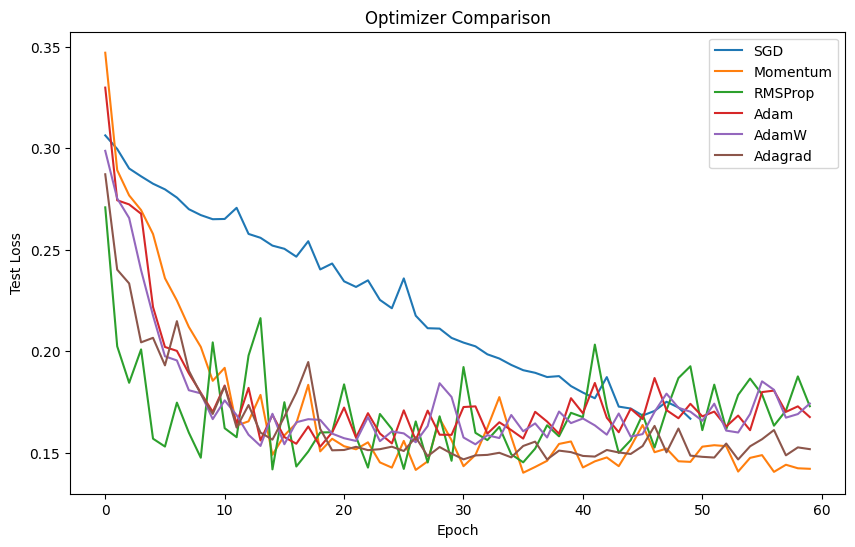

In [20]:
histories = {
    "SGD": sgd_history,
    "Momentum": momentum_history,
    "RMSProp": rmsprop_history,
    "Adam": adam_history,
    "AdamW": adamw_history,
    "Adagrad": adagrad_history,
}

plt.figure(figsize = (10, 6))

for name, history in histories.items():
    plt.plot(history["test_loss"], label = name)

plt.xlabel("Epoch")
plt.ylabel("Test Loss")
plt.title("Optimizer Comparison")
plt.legend()
plt.show()

## Comparing the learning rate strategies

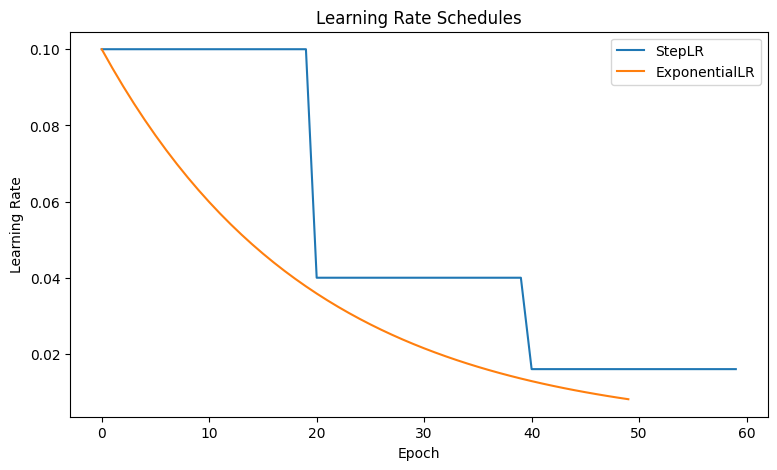

In [21]:
plt.figure(figsize=(9, 5))
plt.plot(scheduler_history["lr"], label="StepLR")
plt.plot(decay_history["lr"], label="ExponentialLR")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Learning Rate Schedules")
plt.legend()
plt.show()

## Conclusion

In [22]:
summary = {
    "Batch Normalization": accuracy(bn_model, test_loader),
    "Dropout": accuracy(dropout_model, test_loader),
    "Early Stopping": accuracy(early_stop_model, test_loader),
    "Momentum": accuracy(momentum_model, test_loader),
    "RMSProp": accuracy(rmsprop_model, test_loader),
    "Adam": accuracy(adam_model, test_loader),
    "AdamW": accuracy(adamw_model, test_loader),
    "Adagrad": accuracy(adagrad_model, test_loader),
    "L1": accuracy(l1_model, test_loader),
    "L2": accuracy(l2_model, test_loader),
}

for technique, score in summary.items():
    print(f"{technique:<20} {score:.4f}")

Batch Normalization  0.9357
Dropout              0.9357
Early Stopping       0.9250
Momentum             0.9286
RMSProp              0.9286
Adam                 0.9214
AdamW                0.9286
Adagrad              0.9393
L1                   0.9286
L2                   0.9286
